# Data Cleaning Process

Data Cleaning is the process of fixing raw data to ensure accuracy and reliability for analysis. This notebook transforms the `raw_data.csv` into a validated, analysis-ready dataset.

**Key Actions Taken:**
* **Imputation**: Filling missing values with the median (robust against skewed data).
* **Outlier Removal**: Dropping unrealistic anomalies (e.g., Warehouse distance > 100).
* **Categorization**: Grouping raw numbers into labels (e.g., Address status) for better insights.
* **Standardization**: Merging duplicate categories (e.g., "Mobile Phone" $\rightarrow$ "Mobile").
* **Optimization**: Setting correct data types (int, category) and saving as Pickle to preserve metadata.

---

## Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---

## Reading Data

In [2]:
data = pd.read_csv('../data/raw_data.csv')

# Data -> DataFrame

# Since modifying the original dataset is not required, we only make changes in the masked dataframe.
df = data.copy()

df.head()


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


---

## General Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


In [4]:
df.shape # rows & columns

(3941, 11)

---

## Handling the first (**Tenure**) column

In [5]:
df.Tenure.unique()

array([15.,  7., 27., 20., 30.,  1., 11., 17.,  6., 16., 10., nan,  8.,
       19.,  0.,  3.,  5.,  9., 18., 12., 24.,  4., 61., 25., 13., 14.,
        2., 21., 29., 26., 23., 31., 22., 28., 51., 60., 50.])

In [6]:
print(f"No. of NULL values in Tenure column: {df.Tenure.isna().sum()}", f"Total no. of records: {df.shape[0]}", \
    f"% of NULL values in Tenure column: {round((df.Tenure.isna().sum() / df.shape[0]) * 100, 2)}%", sep = '\n')
df[df.Tenure.isna()]

No. of NULL values in Tenure column: 194
Total no. of records: 3941
% of NULL values in Tenure column: 4.92%


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
16,NaN,21.0,5,Mobile,1,Married,1,1,3.0,121.68,0
37,NaN,6.0,4,Mobile,5,Married,2,0,2.0,122.18,0
44,NaN,7.0,4,Mobile,3,Married,2,0,0.0,120.08,0
85,NaN,6.0,3,Mobile,1,Married,4,0,2.0,122.70,0
93,NaN,15.0,3,Mobile,1,Married,4,0,3.0,120.75,0
...,...,...,...,...,...,...,...,...,...,...,...
3842,NaN,26.0,3,Mobile,3,Married,5,0,0.0,122.59,0
3853,NaN,28.0,3,Mobile Phone,3,Single,2,1,0.0,116.75,1
3879,NaN,16.0,3,Mobile,4,Married,2,0,2.0,122.97,0
3890,NaN,9.0,3,Mobile Phone,3,Single,2,0,0.0,114.20,1


0.7895705580243476


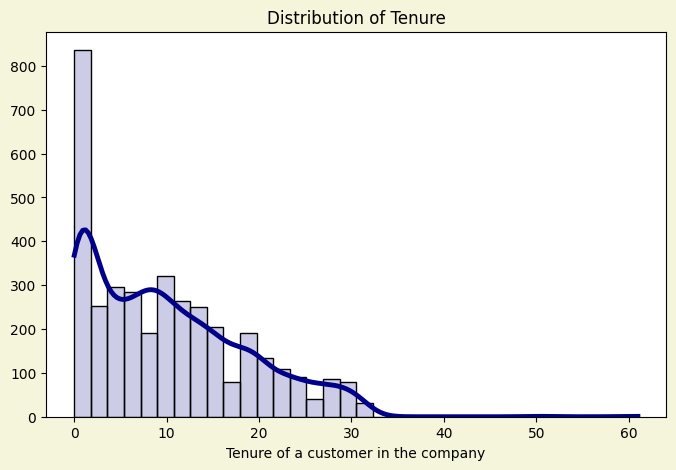

In [7]:
plt.figure(figsize = (8, 5), facecolor = 'beige')
print(df['Tenure'].skew())
sns.histplot(df['Tenure'], color='darkblue', kde = True, line_kws = {'linewidth': '3.5'}, alpha = .2)
# sns.kdeplot(df['Tenure'], color='red')
plt.title("Distribution of Tenure")
plt.xlabel("Tenure of a customer in the company")
plt.ylabel("")
plt.show()

**Observation**: The distribution is positive and right-skewed, thus the average - *mean* - value will not be precise, so the **median** will replace the null values.

In [8]:
print(f"Median of the Tenure column: {df.Tenure.median()}")
df['Tenure'] = df['Tenure'].fillna(df['Tenure'].median())
print(f"No. of missing values: {df.Tenure.isna().sum()}")
df[df.Tenure.isna()]

Median of the Tenure column: 9.0
No. of missing values: 0


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn


**Observation**: Since the `Tenure` column represents a whole number, it should be an **integer** instead of a **float**.

In [9]:
df.Tenure = df.Tenure.astype('int')
# df.info()
df.Tenure.unique()

array([15,  7, 27, 20, 30,  1, 11, 17,  6, 16, 10,  9,  8, 19,  0,  3,  5,
       18, 12, 24,  4, 61, 25, 13, 14,  2, 21, 29, 26, 23, 31, 22, 28, 51,
       60, 50])

---

## Handling the second (**WarehouseToHome**) column 

In [10]:
df.WarehouseToHome.info() # 3941 - 3772 missing values

<class 'pandas.core.series.Series'>
RangeIndex: 3941 entries, 0 to 3940
Series name: WarehouseToHome
Non-Null Count  Dtype  
--------------  -----  
3772 non-null   float64
dtypes: float64(1)
memory usage: 30.9 KB


In [11]:
print(f"No. of NULL values in WarehouseToHome column: {df.WarehouseToHome.isna().sum()}", f"Total no. of records: {df.shape[0]}", \
    f"% of NULL values in WarehouseToHome column: {round((df.WarehouseToHome.isna().sum() / df.shape[0]) * 100, 2)}%", sep = '\n')
df[df.WarehouseToHome.isna()]

No. of NULL values in WarehouseToHome column: 169
Total no. of records: 3941
% of NULL values in WarehouseToHome column: 4.29%


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
27,0,NaN,1,Mobile,3,Single,4,1,3.0,124.32,1
33,0,NaN,4,Mobile,4,Divorced,6,0,1.0,125.46,1
34,0,NaN,4,Mobile,1,Married,6,0,3.0,123.67,1
35,0,NaN,3,Mobile,5,Married,4,0,0.0,123.22,0
57,0,NaN,4,Mobile,4,Married,2,0,3.0,123.68,0
...,...,...,...,...,...,...,...,...,...,...,...
3871,7,NaN,1,Mobile,3,Married,1,0,0.0,125.85,0
3898,0,NaN,3,Mobile,3,Married,2,0,2.0,126.10,1
3900,0,NaN,4,Mobile,1,Single,2,1,0.0,124.39,1
3907,2,NaN,3,Mobile,5,Divorced,8,1,2.0,124.04,1


Skewness: 1.428746201804645


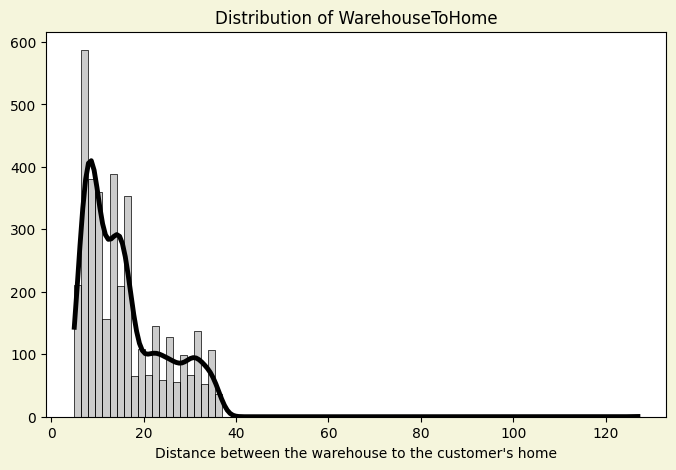

In [12]:
print(f"Skewness: {df['WarehouseToHome'].skew()}")
plt.figure(figsize = (8, 5), facecolor = 'beige')
sns.histplot(df['WarehouseToHome'], color='black', alpha = .2, kde = True, line_kws = {'linewidth': 3.5})
# sns.kdeplot(df['WarehouseToHome'], color='red')
plt.xlabel('Distance between the warehouse to the customer\'s home')
plt.ylabel('')
plt.title("Distribution of WarehouseToHome")
plt.show()

**Observation**: The distribution is positive and right-skewed, thus the average - *mean* - value will not be precise, so the **median** will replace the blank values.

In [13]:
print(f"Median of the WarehouseToHome column: {df.WarehouseToHome.median()}")
df['WarehouseToHome'] = df['WarehouseToHome'].fillna(df['WarehouseToHome'].median())
print(f"No. of missing values: {df.WarehouseToHome.isna().sum()}")
df[df.WarehouseToHome.isna()]

Median of the WarehouseToHome column: 14.0
No. of missing values: 0


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn


**Observation**: Since the `WarehouseToHome` column represents a whole number, it should be an **integer** instead of **float**.

In [14]:
df.WarehouseToHome = df.WarehouseToHome.astype('int')
# df.info()
df.WarehouseToHome.unique()

array([ 29,  25,  13,  15,  16,  11,  12,   7,  26,  20,  14,   8,  21,
        22,  27,  18,  33,   9,  17,   6,  31,  28,  10,  19,  32,  23,
        30,  35,  34,  24,   5,  36, 127])

In [15]:
df.WarehouseToHome.value_counts().sort_index()

WarehouseToHome
5        6
6      205
7      277
8      310
9      380
10     190
11     169
12     157
13     173
14     384
15     210
16     211
17     143
18      65
19      57
20      52
21      67
22      76
23      70
24      58
25      65
26      62
27      55
28      51
29      48
30      66
31      77
32      61
33      52
34      43
35      64
36      36
127      1
Name: count, dtype: int64

**Outlier**: It is highly unlikely that the distance between the Warehouse and someone's Home is 127 units (mile or km). The difference between the two highest numbers of `WarehouseToHome` is 91 units. There is only one such big number. Hereafter we consider this anomaly an outlier.

In [16]:
df[df.WarehouseToHome < 100].sort_values(by = 'WarehouseToHome', ascending = False)

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
1079,19,36,4,Mobile Phone,1,Single,7,0,4.0,159.52,0
2668,1,36,5,Laptop & Accessory,3,Single,3,0,9.0,170.08,1
2309,4,36,4,Laptop & Accessory,5,Married,10,0,4.0,166.15,0
1734,26,36,4,Mobile Phone,1,Married,4,0,1.0,159.82,0
941,22,36,4,Fashion,3,Married,5,0,1.0,250.04,0
...,...,...,...,...,...,...,...,...,...,...,...
1002,1,5,5,Mobile Phone,4,Married,3,0,1.0,150.96,1
197,0,5,4,Mobile,3,Single,2,0,2.0,130.33,0
2480,8,5,3,Fashion,5,Married,2,0,8.0,190.69,0
3840,12,5,4,Others,2,Divorced,2,0,3.0,292.72,0


In [17]:
df = df[df.WarehouseToHome < 100]

In [18]:
df.reset_index(drop=True, inplace = True) # to handle the missing index 
# drop = True to drop the unnecessary Index column
# inplace = True to do it in this section of the code without returning anythig

---

## Handling the third (**NumberOfDeviceRegistered**) column

In [19]:
print(f"No. of NULL values in NumberOfDeviceRegistered column: {df.NumberOfDeviceRegistered.isna().sum()}")

No. of NULL values in NumberOfDeviceRegistered column: 0


In [20]:
df.NumberOfDeviceRegistered.unique()

array([4, 3, 6, 2, 5, 1], dtype=int64)

In [21]:
df.NumberOfDeviceRegistered.value_counts()

NumberOfDeviceRegistered
4    1693
3    1193
5     591
2     192
1     164
6     107
Name: count, dtype: int64

**Observation**: The third column (`NumberOfDeviceRegistered`) needs no intervention.

---

## Handling the fourth (**PreferedOrderCat**) column

In [22]:
df.columns[3]

'PreferedOrderCat'

In [23]:
df.PreferedOrderCat.unique() # Mobile & Mobile Phone

array(['Laptop & Accessory', 'Mobile', 'Fashion', 'Others',
       'Mobile Phone', 'Grocery'], dtype=object)

**Observation**: Records containing these values **represent** the same (*Phone* or *Mobile Phone*) category. 

In [24]:
df.PreferedOrderCat = df.PreferedOrderCat.replace('Mobile Phone', 'Mobile')
df.PreferedOrderCat.unique() # corrected

array(['Laptop & Accessory', 'Mobile', 'Fashion', 'Others', 'Grocery'],
      dtype=object)

**Observation**: a final modification could be converting the type from **object** to **string**.

In [25]:
df.PreferedOrderCat = df.PreferedOrderCat.astype('string')
df.PreferedOrderCat.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3940 entries, 0 to 3939
Series name: PreferedOrderCat
Non-Null Count  Dtype 
--------------  ----- 
3940 non-null   string
dtypes: string(1)
memory usage: 30.9 KB


Text(0.5, 1.0, 'Distribution of Preferred Order Categories')

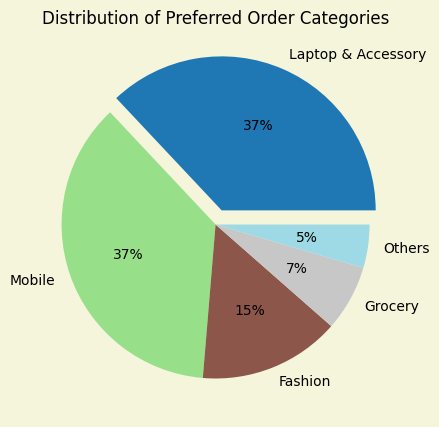

In [26]:
plt.figure(figsize=(15, 5), facecolor = 'beige')
df.PreferedOrderCat.value_counts().plot(kind = 'pie', autopct = "%.0f%%", explode = [.1, 0, 0, 0, 0], colormap = 'tab20', ylabel = "")
plt.title("Distribution of Preferred Order Categories")


---

## Handling the fifth (**SatisfactionScore**) column

In [27]:
df.columns[4] # SatisfactionScore

'SatisfactionScore'

In [28]:
df.SatisfactionScore.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3940 entries, 0 to 3939
Series name: SatisfactionScore
Non-Null Count  Dtype
--------------  -----
3940 non-null   int64
dtypes: int64(1)
memory usage: 30.9 KB


In [29]:
df.SatisfactionScore.unique()

array([3, 1, 4, 2, 5], dtype=int64)

In [30]:
df.SatisfactionScore.value_counts().sort_index()

SatisfactionScore
1     804
2     392
3    1190
4     758
5     796
Name: count, dtype: int64

In [31]:
perc = []
for pos, element in enumerate(df.SatisfactionScore.value_counts().sort_index()):
    # print(pos, element)
    perc.append(f"{(element / df.shape[0]):.2%}")
print(perc)

['20.41%', '9.95%', '30.20%', '19.24%', '20.20%']


C:\Users\Erwin\AppData\Local\Temp\ipykernel_6312\3084802170.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = df.SatisfactionScore.value_counts().sort_index().index, y = df.SatisfactionScore.value_counts().sort_index().values, palette = 'tab10')


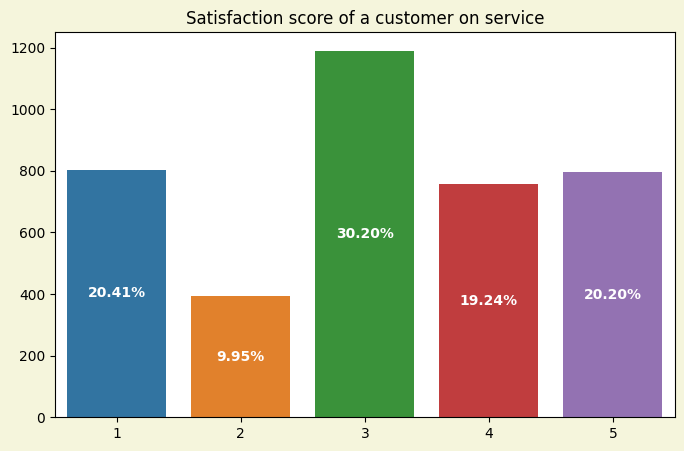

In [32]:
plt.subplots(figsize = (8, 5), facecolor = 'beige')
sns.barplot(x = df.SatisfactionScore.value_counts().sort_index().index, y = df.SatisfactionScore.value_counts().sort_index().values, palette = 'tab10')
plt.ylabel("")
plt.xlabel("")
plt.title('Satisfaction score of a customer on service')
for pos, el in enumerate(df.SatisfactionScore.value_counts().sort_index()):
    plt.text(pos, el / 2, perc[pos], ha = 'center', va = 'center', color = 'white', fontweight='bold')
    # plt.text(x, y, etc.)
plt.show()

**Observation**: For clearer understanding we will create a copy of this column and rename the scores (1-5) to nominal values in order to let them have a deeper meaning.

In [33]:
df['Satisfaction_Label'] = df.SatisfactionScore.copy()

In [34]:
new_names = {
    1: 'Bad',
    2: 'Not Bad',
    3: 'Neutral',
    4: 'Good',
    5: 'Best'
}

In [35]:
# mapping (renaming) the items
df.Satisfaction_Label = df.Satisfaction_Label.map(new_names)
df.Satisfaction_Label

0       Neutral
1           Bad
2           Bad
3       Neutral
4          Good
         ...   
3935    Neutral
3936    Not Bad
3937    Neutral
3938    Neutral
3939       Best
Name: Satisfaction_Label, Length: 3940, dtype: object

In [36]:
order = ['Bad', 'Not Bad', 'Neutral', 'Good', 'Best']
perc = [f"{(val / df.shape[0]):.2%}" for val in df.Satisfaction_Label.value_counts().reindex(order)]
df[['SatisfactionScore', 'Satisfaction_Label']]

,SatisfactionScore,Satisfaction_Label
0,3,Neutral
1,1,Bad
2,1,Bad
3,3,Neutral
4,4,Good
...,...,...
3935,3,Neutral
3936,2,Not Bad
3937,3,Neutral
3938,3,Neutral


**Observation**: a final modification could be converting the type from **object** to **string**.

In [37]:
df.Satisfaction_Label = df.Satisfaction_Label.astype('string')
df.Satisfaction_Label.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3940 entries, 0 to 3939
Series name: Satisfaction_Label
Non-Null Count  Dtype 
--------------  ----- 
3940 non-null   string
dtypes: string(1)
memory usage: 30.9 KB


C:\Users\Erwin\AppData\Local\Temp\ipykernel_6312\3129893640.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.Satisfaction_Label.value_counts().reindex(order).index, y=df.Satisfaction_Label.value_counts().reindex(order).values, palette='tab10', legend=False)


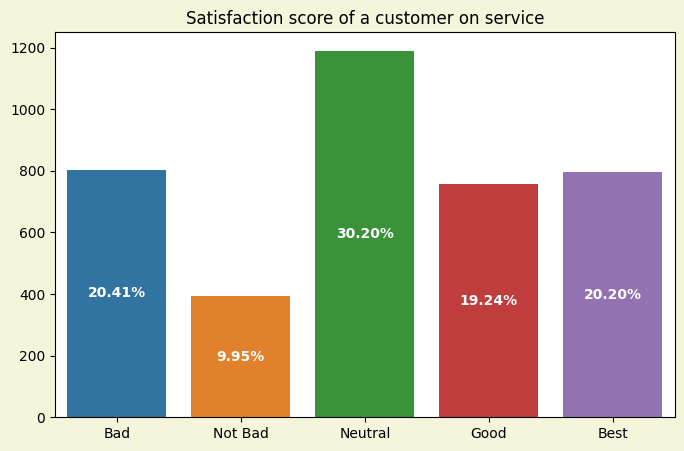

In [38]:
plt.figure(figsize=(8, 5), facecolor='beige')
sns.barplot(x=df.Satisfaction_Label.value_counts().reindex(order).index, y=df.Satisfaction_Label.value_counts().reindex(order).values, palette='tab10', legend=False)

plt.title('Satisfaction score of a customer on service')
plt.ylabel("")
plt.xlabel("")

for pos, el in enumerate(df.Satisfaction_Label.value_counts().reindex(order)):
    plt.text(pos, el / 2, perc[pos], ha='center', va='center', color='white', fontweight='bold')

plt.show()

---

## Handling the sixth (**MaritalStatus**) column

In [39]:
df.columns[5]

'MaritalStatus'

In [40]:
df.MaritalStatus.unique()

array(['Single', 'Married', 'Divorced'], dtype=object)

In [41]:
df.MaritalStatus.value_counts()

MaritalStatus
Married     2054
Single      1310
Divorced     576
Name: count, dtype: int64

**Observation**: a final modification could be converting the type from **object** to **string**.

In [42]:
df.MaritalStatus = df.MaritalStatus.astype('string')
df.MaritalStatus.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3940 entries, 0 to 3939
Series name: MaritalStatus
Non-Null Count  Dtype 
--------------  ----- 
3940 non-null   string
dtypes: string(1)
memory usage: 30.9 KB


---

## Handling the seventh (**NumberOfAddress**) column

In [43]:
df.columns[6]

'NumberOfAddress'

In [44]:
df.NumberOfAddress.unique()

array([ 2,  5,  7,  8,  3,  1,  9,  4, 10, 11,  6, 19, 22, 21],
      dtype=int64)

In [45]:
df.NumberOfAddress.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3940 entries, 0 to 3939
Series name: NumberOfAddress
Non-Null Count  Dtype
--------------  -----
3940 non-null   int64
dtypes: int64(1)
memory usage: 30.9 KB


In [46]:
df.NumberOfAddress.describe()

count    3940.000000
mean        4.237817
std         2.627030
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        22.000000
Name: NumberOfAddress, dtype: float64

In [47]:
pd.concat([df.NumberOfAddress.nlargest(5), df.NumberOfAddress.nsmallest(5)]).rename('Top 5 & Bottom 5')

2109    22
3493    21
1581    19
29      11
39      11
16       1
30       1
60       1
66       1
76       1
Name: Top 5 & Bottom 5, dtype: int64

In [48]:
df.NumberOfAddress.value_counts().sort_index()
# print(f"Number of people who have more than 10 addresses: {df[df.NumberOfAddress > 10]}")
# df[df.NumberOfAddress > 10]

NumberOfAddress
1     266
2     963
3     887
4     405
5     384
6     263
7     174
8     204
9     171
10    145
11     75
19      1
21      1
22      1
Name: count, dtype: int64

**Observation**: The records between 19 and 22 have only 1 counted pair for each. They could be considered outliers. Furthermore, it is highly unusual that one person has more than 10 addresses. However, since there is a significant cluster at 11 addresses (75 records), these values are considered legitimate data points rather than recording errors. Although for the better understanding we create a new column categorizing the records: "*Below 5 Addresses*", "*Below 10 Addresses*" and "*10+ Addresses*" which makes more sense in the future when visualizing the data.

Other intervention is not needed in this column.

In [49]:
df = df[df['NumberOfAddress'].values <= 11] # outlier handling
df.reset_index(drop=True, inplace=True) # to handle the missing indexes
df.NumberOfAddress.value_counts()

NumberOfAddress
2     963
3     887
4     405
5     384
1     266
6     263
8     204
7     174
9     171
10    145
11     75
Name: count, dtype: int64

In [50]:
df['Address_status'] = df.NumberOfAddress.apply(lambda x:'1-5' if x <= 5 else ('6-10' if x > 5 and x <= 10  else '10+'))
# df[['NumberOfAddress', 'Address_status']]
print(df.NumberOfAddress.value_counts().sort_index(), df.Address_status.value_counts())

NumberOfAddress
1     266
2     963
3     887
4     405
5     384
6     263
7     174
8     204
9     171
10    145
11     75
Name: count, dtype: int64 Address_status
1-5     2905
6-10     957
10+       75
Name: count, dtype: int64


**Observation**: a final modification could be converting the type from **object** to **string**.

In [51]:
df.Address_status = df.Address_status.astype('string')
df.Address_status.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3937 entries, 0 to 3936
Series name: Address_status
Non-Null Count  Dtype 
--------------  ----- 
3937 non-null   string
dtypes: string(1)
memory usage: 30.9 KB


---

## Handling the eighth (**Complain**) column

In [52]:
print(df.columns[7])
df.columns

Complain


Index(['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
       'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus',
       'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount',
       'Churn', 'Satisfaction_Label', 'Address_status'],
      dtype='object')

In [53]:
print(df.Complain.unique())
df.Complain.value_counts()

[0 1]


Complain
0    2825
1    1112
Name: count, dtype: int64

**Observation**: 1 and 0 mean True and False. No need to convert them to **boolean** datatype. No intervention needed.

---

## Handling the ninth (**DaySinceLastOrder**) column

In [54]:
df.columns[8]

'DaySinceLastOrder'

In [55]:
print(df.DaySinceLastOrder.unique())
df.DaySinceLastOrder.value_counts().sort_index()

[ 7. nan  8. 11.  2.  1.  4.  3.  6.  0. 14.  9. 10. 12.  5. 17. 30. 18.
 16. 13. 15. 46. 31.]


DaySinceLastOrder
0.0     344
1.0     437
2.0     546
3.0     631
4.0     311
5.0     155
6.0      81
7.0     314
8.0     382
9.0     208
10.0    111
11.0     58
12.0     42
13.0     33
14.0     28
15.0     13
16.0      8
17.0     12
18.0      7
30.0      1
31.0      1
46.0      1
Name: count, dtype: int64

In [56]:
# number of missing values
print(f"Total no. of records: {df.DaySinceLastOrder.shape[0]}")
print(f"No. of missing data: {df.DaySinceLastOrder.isna().sum()}")
print(f"Number of non-null data: {df.shape[0] - df.DaySinceLastOrder.isna().sum()}")
print(f"Percentage of missing data: {(df.DaySinceLastOrder.isna().sum() / df.shape[0]):.2%}")

Total no. of records: 3937
No. of missing data: 213
Number of non-null data: 3724
Percentage of missing data: 5.41%


**Observation**: Since the percentage of missing data is significantly higher than expected, removing these records might lead to a loss of important information. (Therefore, they will be replaced with the **median**, as the distribution is right-skewed.) First, a more precise analysis could help when investigating missing data, as other parameters or columns might provide further details.

In [57]:
df.DaySinceLastOrder = df.DaySinceLastOrder.fillna('?')
print(df.DaySinceLastOrder.unique())
df.DaySinceLastOrder.value_counts()

[7.0 '?' 8.0 11.0 2.0 1.0 4.0 3.0 6.0 0.0 14.0 9.0 10.0 12.0 5.0 17.0 30.0
 18.0 16.0 13.0 15.0 46.0 31.0]


DaySinceLastOrder
3.0     631
2.0     546
1.0     437
8.0     382
0.0     344
7.0     314
4.0     311
?       213
9.0     208
5.0     155
10.0    111
6.0      81
11.0     58
12.0     42
13.0     33
14.0     28
15.0     13
17.0     12
16.0      8
18.0      7
30.0      1
46.0      1
31.0      1
Name: count, dtype: int64

In [58]:
df[df.DaySinceLastOrder == '?']

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,Satisfaction_Label,Address_status
3,20,25,4,Fashion,3,Divorced,7,0,?,230.27,0,Neutral,6-10
10,6,26,6,Fashion,3,Married,5,0,?,221.10,0,Neutral,1-5
13,1,7,5,Fashion,3,Divorced,7,0,?,231.09,1,Neutral,6-10
29,1,17,5,Fashion,5,Married,11,0,?,228.06,1,Best,10+
52,16,9,4,Fashion,1,Married,4,1,?,226.24,0,Bad,1-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3832,28,8,4,Fashion,3,Married,9,0,?,230.02,0,Neutral,6-10
3839,13,7,2,Fashion,1,Married,2,0,?,221.13,0,Bad,1-5
3888,20,7,4,Fashion,5,Married,9,0,?,218.96,0,Best,6-10
3890,9,24,4,Laptop & Accessory,5,Divorced,5,1,?,214.66,0,Best,1-5


In [59]:
print(df[df.DaySinceLastOrder == '?'].info())
df[df.DaySinceLastOrder == '?'].describe()

<class 'pandas.core.frame.DataFrame'>
Index: 213 entries, 3 to 3900
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    213 non-null    int32  
 1   WarehouseToHome           213 non-null    int32  
 2   NumberOfDeviceRegistered  213 non-null    int64  
 3   PreferedOrderCat          213 non-null    string 
 4   SatisfactionScore         213 non-null    int64  
 5   MaritalStatus             213 non-null    string 
 6   NumberOfAddress           213 non-null    int64  
 7   Complain                  213 non-null    int64  
 8   DaySinceLastOrder         213 non-null    object 
 9   CashbackAmount            213 non-null    float64
 10  Churn                     213 non-null    int64  
 11  Satisfaction_Label        213 non-null    string 
 12  Address_status            213 non-null    string 
dtypes: float64(1), int32(2), int64(5), object(1), string(4)
memory usage:

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,CashbackAmount,Churn
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000
mean,11.530516,15.647887,4.103286,2.915493,4.877934,0.272300,220.923052,0.187793
std,8.281330,8.079963,0.894764,1.418342,2.606981,0.446192,6.621594,0.391467
min,0.000000,6.000000,1.000000,1.000000,1.000000,0.000000,209.340000,0.000000
25%,5.000000,9.000000,4.000000,2.000000,3.000000,0.000000,214.980000,0.000000
50%,10.000000,14.000000,4.000000,3.000000,4.000000,0.000000,221.690000,0.000000
75%,17.000000,19.000000,5.000000,4.000000,6.000000,1.000000,227.090000,0.000000
max,31.000000,36.000000,6.000000,5.000000,11.000000,1.000000,231.420000,1.000000


**Observation**: Since there is nothing peculiar or lead-following in the data, we are going to see if this column's distrubution is gaussian/normal or not.

1.3366278410379795


Text(0.5, 1.0, 'Distribution of Day Since Last Order')

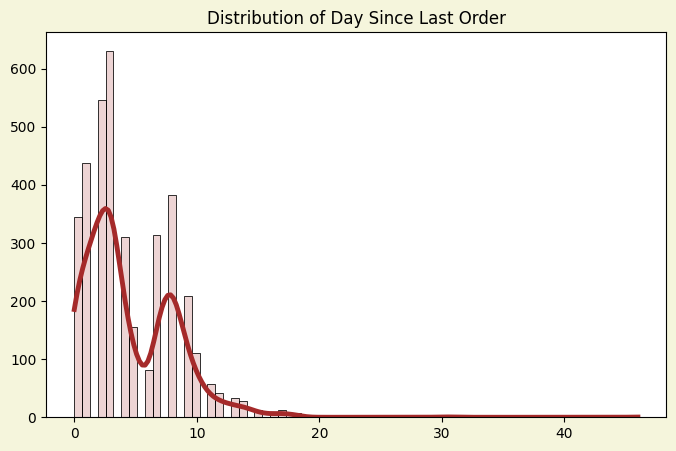

In [60]:
print(df.DaySinceLastOrder[df.DaySinceLastOrder != '?'].skew())
plt.figure(figsize = (8, 5), facecolor = 'beige')
sns.histplot(df.DaySinceLastOrder[df.DaySinceLastOrder != '?'], kde = True, alpha = .2, line_kws = {'linewidth': 3.5}, color = 'brown')
plt.ylabel("")
plt.xlabel("")
plt.title("Distribution of Day Since Last Order")

**Observation**: The data's distribution is evidently right-skewed. Average value would ruin the validity of data, that is why we are going to use **median** to fill in the gap.

In [61]:
print(f"Median: {df.DaySinceLastOrder[df.DaySinceLastOrder != '?'].median()}")
df.DaySinceLastOrder.replace('?', df.DaySinceLastOrder[df.DaySinceLastOrder != '?'].median(), inplace = True)
print(df.DaySinceLastOrder.unique())

Median: 3.0
[ 7.  3.  8. 11.  2.  1.  4.  6.  0. 14.  9. 10. 12.  5. 17. 30. 18. 16.
 13. 15. 46. 31.]


In [62]:
df.DaySinceLastOrder.dtype

dtype('float64')

**Observation**: Now we can convert the type of values to be **int** instead of **float**, because there are no fractional days, only whole days (whole numbers).

In [63]:
df.DaySinceLastOrder = df.DaySinceLastOrder.astype('int')
df.DaySinceLastOrder.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3937 entries, 0 to 3936
Series name: DaySinceLastOrder
Non-Null Count  Dtype
--------------  -----
3937 non-null   int32
dtypes: int32(1)
memory usage: 15.5 KB


---

## Handling the tenth (**CashbackAmount**) column

In [64]:
df.columns[9]

'CashbackAmount'

In [65]:
df.CashbackAmount.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3937 entries, 0 to 3936
Series name: CashbackAmount
Non-Null Count  Dtype  
--------------  -----  
3937 non-null   float64
dtypes: float64(1)
memory usage: 30.9 KB


In [66]:
df.CashbackAmount.describe()

count    3937.000000
mean      176.723553
std        48.807396
min         0.000000
25%       145.700000
50%       163.340000
75%       195.260000
max       324.990000
Name: CashbackAmount, dtype: float64

In [67]:
df.CashbackAmount.value_counts().sort_index(ascending = False)

CashbackAmount
324.99    2
324.73    2
324.43    1
324.26    1
323.59    1
         ..
56.00     1
37.00     1
25.00     3
12.00     1
0.00      3
Name: count, Length: 2334, dtype: int64

In [68]:
print(f"No. of missing data: {df.CashbackAmount.isnull().sum()}")

No. of missing data: 0


**Observation**: Everything seems to be in order. No missing data, correct data type, sufficient variance in the data. Intervention is not needed. However a new column could be created with the categorized values of the original one such as: Minor (cashback below 100$), Medium (cashback between 100$ and 300$) and Major (above 300$).

In [69]:
bins = [0, 100, 300, df.CashbackAmount.max()]
df['Cashback_status'] = pd.cut(df.CashbackAmount, bins = bins, labels = ['Minor (< 100$)', 'Medium (100-300$)', 'Major (300$+)'], include_lowest = True)
# category data type
df[['CashbackAmount', 'Cashback_status']]

,CashbackAmount,Cashback_status
0,143.32,Medium (100-300$)
1,129.29,Medium (100-300$)
2,168.54,Medium (100-300$)
3,230.27,Medium (100-300$)
4,322.17,Major (300$+)
...,...,...
3932,231.86,Medium (100-300$)
3933,157.80,Medium (100-300$)
3934,156.60,Medium (100-300$)
3935,124.37,Medium (100-300$)


In [70]:
df.Cashback_status.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3937 entries, 0 to 3936
Series name: Cashback_status
Non-Null Count  Dtype   
--------------  -----   
3937 non-null   category
dtypes: category(1)
memory usage: 4.1 KB


**Observation**: After a thorough analysis it is clear that some previous columns' data types have been changed. Although they are correct in their current form, for a better understanding and a cleaner code structure, an ultimate modification is applied.

The following columns are converted to **category** data type (such as the `Cashback_status`): 
* `PreferedOrderCat`: Mobile, Laptop, etc.
* `MaritalStatus`: Single, Married, etc.
* `Satisfaction_Label`: Bad, Neutral, etc.
* `Address_status`: 1-5, 5-10, etc.

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3937 entries, 0 to 3936
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Tenure                    3937 non-null   int32   
 1   WarehouseToHome           3937 non-null   int32   
 2   NumberOfDeviceRegistered  3937 non-null   int64   
 3   PreferedOrderCat          3937 non-null   string  
 4   SatisfactionScore         3937 non-null   int64   
 5   MaritalStatus             3937 non-null   string  
 6   NumberOfAddress           3937 non-null   int64   
 7   Complain                  3937 non-null   int64   
 8   DaySinceLastOrder         3937 non-null   int32   
 9   CashbackAmount            3937 non-null   float64 
 10  Churn                     3937 non-null   int64   
 11  Satisfaction_Label        3937 non-null   string  
 12  Address_status            3937 non-null   string  
 13  Cashback_status           3937 non-null   catego

In [72]:
cat_columns = ['PreferedOrderCat', 'MaritalStatus', 'Satisfaction_Label', 'Address_status']
for col in cat_columns:
    df[col] = df[col].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3937 entries, 0 to 3936
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Tenure                    3937 non-null   int32   
 1   WarehouseToHome           3937 non-null   int32   
 2   NumberOfDeviceRegistered  3937 non-null   int64   
 3   PreferedOrderCat          3937 non-null   category
 4   SatisfactionScore         3937 non-null   int64   
 5   MaritalStatus             3937 non-null   category
 6   NumberOfAddress           3937 non-null   int64   
 7   Complain                  3937 non-null   int64   
 8   DaySinceLastOrder         3937 non-null   int32   
 9   CashbackAmount            3937 non-null   float64 
 10  Churn                     3937 non-null   int64   
 11  Satisfaction_Label        3937 non-null   category
 12  Address_status            3937 non-null   category
 13  Cashback_status           3937 non-null   catego

In [73]:
df # check

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,Satisfaction_Label,Address_status,Cashback_status
0,15,29,4,Laptop & Accessory,3,Single,2,0,7,143.32,0,Neutral,1-5,Medium (100-300$)
1,7,25,4,Mobile,1,Married,2,0,7,129.29,0,Bad,1-5,Medium (100-300$)
2,27,13,3,Laptop & Accessory,1,Married,5,0,7,168.54,0,Bad,1-5,Medium (100-300$)
3,20,25,4,Fashion,3,Divorced,7,0,3,230.27,0,Neutral,6-10,Medium (100-300$)
4,30,15,4,Others,4,Single,8,0,8,322.17,0,Good,6-10,Major (300$+)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3932,28,9,5,Fashion,3,Married,8,0,1,231.86,0,Neutral,6-10,Medium (100-300$)
3933,8,7,2,Mobile,2,Single,4,0,4,157.80,0,Not Bad,1-5,Medium (100-300$)
3934,30,6,5,Laptop & Accessory,3,Married,3,1,2,156.60,0,Neutral,1-5,Medium (100-300$)
3935,6,14,4,Mobile,3,Married,10,1,0,124.37,1,Neutral,6-10,Medium (100-300$)


---

## Handling the last (**Churn**) column

In [74]:
df.columns

Index(['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
       'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus',
       'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount',
       'Churn', 'Satisfaction_Label', 'Address_status', 'Cashback_status'],
      dtype='object')

In [75]:
df.Churn.info()

<class 'pandas.core.series.Series'>
RangeIndex: 3937 entries, 0 to 3936
Series name: Churn
Non-Null Count  Dtype
--------------  -----
3937 non-null   int64
dtypes: int64(1)
memory usage: 30.9 KB


In [76]:
print(f"No. of missing value: {df.Churn.isnull().sum()}")

No. of missing value: 0


In [77]:
df.Churn.unique()

array([0, 1], dtype=int64)

In [78]:
df.Churn.value_counts()

Churn
0    3264
1     673
Name: count, dtype: int64

**Observation**: There is nothing to be modified. Everything is adequate as it is.

---

## **Duplicated Values**

### Number of duplicates

In [79]:
df.duplicated().sum()

673

**Observation:** Regarding the 673 duplicates identified -- Since the dataset lacks a unique identifier (like a Customer ID), we have opted to retain these records. In a real-world scenario, multiple customers may share identical attributes (marital status, satisfaction, etc.) without being the same person. Removing them without verification could lead to a significant loss of valid behavioral data.

### Keeping the first element (Not Recommended)

In [80]:
# df.drop_duplicates(keep = 'first', inplace = True)

# Saving the (corrected) Data

**Observation**: Instead of saving to a .csv file, we choose the **Pickle** format to preserve Pandas metadata (such as categorized data types), which would be lost in a standard CSV format.

In [81]:
df.to_pickle('../data/cleaned_data.pickle')

In [82]:
df_cleaned = pd.read_pickle('../data/cleaned_data.pickle')
df_cleaned.head() # checking the saved dataset

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,Satisfaction_Label,Address_status,Cashback_status
0,15,29,4,Laptop & Accessory,3,Single,2,0,7,143.32,0,Neutral,1-5,Medium (100-300$)
1,7,25,4,Mobile,1,Married,2,0,7,129.29,0,Bad,1-5,Medium (100-300$)
2,27,13,3,Laptop & Accessory,1,Married,5,0,7,168.54,0,Bad,1-5,Medium (100-300$)
3,20,25,4,Fashion,3,Divorced,7,0,3,230.27,0,Neutral,6-10,Medium (100-300$)
4,30,15,4,Others,4,Single,8,0,8,322.17,0,Good,6-10,Major (300$+)


In [83]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3937 entries, 0 to 3936
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Tenure                    3937 non-null   int32   
 1   WarehouseToHome           3937 non-null   int32   
 2   NumberOfDeviceRegistered  3937 non-null   int64   
 3   PreferedOrderCat          3937 non-null   category
 4   SatisfactionScore         3937 non-null   int64   
 5   MaritalStatus             3937 non-null   category
 6   NumberOfAddress           3937 non-null   int64   
 7   Complain                  3937 non-null   int64   
 8   DaySinceLastOrder         3937 non-null   int32   
 9   CashbackAmount            3937 non-null   float64 
 10  Churn                     3937 non-null   int64   
 11  Satisfaction_Label        3937 non-null   category
 12  Address_status            3937 non-null   category
 13  Cashback_status           3937 non-null   catego